# 03. Эксперименты и тюнинг

Цель: подбор гиперпараметров, анализ аугментаций, выбор финальной модели.

In [7]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import seaborn as sns

from src.data.dataset import SteelDataset, default_train_transforms, default_val_transforms, CLASS_NAMES
from src.data.split import stratified_split
from src.models.model import create_model
from src.train import train_one_epoch, validate

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


### 1. Эксперимент: learning rate

In [ ]:
def run_experiment(model_name, lr, epochs=10):
    full_dataset = SteelDataset(root_dir='../data/train', is_train=True, image_size=224)
    train_ds, val_ds, _ = stratified_split(full_dataset)
    val_ds.dataset.transform = default_val_transforms(224)
    
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
    
    model = create_model(model_name, num_classes=6, pretrained=True, device=device.type)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    
    best_val_acc = 0.0
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)
        best_val_acc = max(best_val_acc, val_acc)
    
    return best_val_acc

lrs = [1e-4, 3e-4, 1e-3, 3e-3]
results = []
for lr in lrs:
    acc = run_experiment('mobilenet_v2', lr, epochs=8)
    results.append({'lr': lr, 'best_val_acc': acc})
    print(f"LR={lr:.0e}: best_val_acc={acc:.4f}")

df_lr = pd.DataFrame(results)
print(df_lr)

2026-05-24 11:34:32,406 [INFO] src.data.dataset: Loaded 1440 samples from ../data/train
2026-05-24 11:34:32,455 [INFO] src.models.model: Created mobilenet_v2 with 6 classes on cpu
2026-05-24 11:40:58,940 [INFO] src.data.dataset: Loaded 1440 samples from ../data/train
2026-05-24 11:40:58,983 [INFO] src.models.model: Created mobilenet_v2 with 6 classes on cpu


LR=1e-04: best_val_acc=1.0000


2026-05-24 11:47:40,064 [INFO] src.data.dataset: Loaded 1440 samples from ../data/train
2026-05-24 11:47:40,108 [INFO] src.models.model: Created mobilenet_v2 with 6 classes on cpu


LR=3e-04: best_val_acc=1.0000


2026-05-24 11:54:36,191 [INFO] src.data.dataset: Loaded 1440 samples from ../data/train
2026-05-24 11:54:36,234 [INFO] src.models.model: Created mobilenet_v2 with 6 classes on cpu


LR=1e-03: best_val_acc=1.0000


LR=3e-03: best_val_acc=0.9722
       lr  best_val_acc
0  0.0001      1.000000
1  0.0003      1.000000
2  0.0010      1.000000
3  0.0030      0.972222


### 2. Эксперимент: аугментации

In [4]:
import torchvision.transforms as T

aug_configs = {
    'No aug': T.Compose([
        T.Resize(256), T.CenterCrop(224),
        T.ToTensor(), T.Normalize([0.5]*3, [0.5]*3),
    ]),
    'Light': T.Compose([
        T.Resize(256), T.RandomCrop(224), T.RandomHorizontalFlip(p=0.5),
        T.ToTensor(), T.Normalize([0.5]*3, [0.5]*3),
    ]),
    'Strong': T.Compose([
        T.Resize(256), T.RandomCrop(224), T.RandomHorizontalFlip(p=0.5),
        T.RandomRotation(15), T.ColorJitter(0.1, 0.1, 0.05, 0.05),
        T.ToTensor(), T.Normalize([0.5]*3, [0.5]*3),
    ]),
}

aug_results = []
for aug_name, aug_transform in aug_configs.items():
    full_dataset = SteelDataset(root_dir='../data/train', is_train=True, image_size=224)
    train_ds, val_ds, _ = stratified_split(full_dataset)
    train_ds.dataset.transform = aug_transform
    val_ds.dataset.transform = default_val_transforms(224)
    
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
    
    model = create_model('mobilenet_v2', num_classes=6, pretrained=True, device=device.type)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    
    for epoch in range(10):
        train_one_epoch(model, train_loader, criterion, optimizer, device)
        _, val_acc, _, _ = validate(model, val_loader, criterion, device)
    
    aug_results.append({'augmentation': aug_name, 'val_acc': val_acc})
    print(f"{aug_name}: val_acc={val_acc:.4f}")

df_aug = pd.DataFrame(aug_results)
print(df_aug)

2026-05-24 12:10:36,718 [INFO] src.data.dataset: Loaded 1440 samples from ../data/train
2026-05-24 12:10:36,773 [INFO] src.models.model: Created mobilenet_v2 with 6 classes on cpu
2026-05-24 12:19:31,771 [INFO] src.data.dataset: Loaded 1440 samples from ../data/train
2026-05-24 12:19:31,813 [INFO] src.models.model: Created mobilenet_v2 with 6 classes on cpu


No aug: val_acc=0.9861


2026-05-24 12:28:20,075 [INFO] src.data.dataset: Loaded 1440 samples from ../data/train
2026-05-24 12:28:20,116 [INFO] src.models.model: Created mobilenet_v2 with 6 classes on cpu


Light: val_acc=0.9931


Strong: val_acc=0.9792
  augmentation   val_acc
0       No aug  0.986111
1        Light  0.993056
2       Strong  0.979167


### 3. Финальная модель

По результатам экспериментов выбираем:
- Модель: ResNet18 или MobileNetV2 (по лучшей accuracy)
- Learning rate: из эксперимента 1
- Аугментации: из эксперимента 2

In [5]:
# Финальное обучение на полном train, оценка на test
full_dataset = SteelDataset(root_dir='../data/train', is_train=True, image_size=224)
train_ds, val_ds, test_ds = stratified_split(full_dataset)

val_ds.dataset.transform = default_val_transforms(224)
test_ds.dataset.transform = default_val_transforms(224)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

model = create_model('mobilenet_v2', num_classes=6, pretrained=True, device=device.type)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)

best_acc = 0.0
for epoch in range(30):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)
    scheduler.step(val_loss)
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), '../artifacts/best_model.pth')
    
    print(f"Epoch {epoch+1:2d} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

# Финальная оценка на тесте
model.load_state_dict(torch.load('../artifacts/best_model.pth'))
test_loss, test_acc, test_preds, test_labels = validate(model, test_loader, criterion, device)
print(f"\nTest Accuracy: {test_acc:.4f}")

2026-05-24 12:37:06,670 [INFO] src.data.dataset: Loaded 1440 samples from ../data/train
2026-05-24 12:37:06,732 [INFO] src.models.model: Created mobilenet_v2 with 6 classes on cpu


Epoch  1 | Train Acc: 0.9201 | Val Acc: 0.6458


Epoch  2 | Train Acc: 0.9618 | Val Acc: 0.9583


Epoch  3 | Train Acc: 0.9688 | Val Acc: 0.9722


Epoch  4 | Train Acc: 0.9800 | Val Acc: 1.0000


...

Epoch 27 | Train Acc: 1.0000 | Val Acc: 0.9931


Epoch 28 | Train Acc: 0.9983 | Val Acc: 0.9931


Epoch 29 | Train Acc: 0.9957 | Val Acc: 0.9931


Epoch 30 | Train Acc: 0.9991 | Val Acc: 0.9931



Test Accuracy: 0.9931


                 precision    recall  f1-score   support

        crazing       1.00      0.96      0.98        24
      inclusion       1.00      1.00      1.00        24
        patches       0.96      1.00      0.98        24
 pitted_surface       1.00      1.00      1.00        24
rolled-in_scale       1.00      1.00      1.00        24
      scratches       1.00      1.00      1.00        24

       accuracy                           0.99       144
      macro avg       0.99      0.99      0.99       144
   weighted avg       0.99      0.99      0.99       144



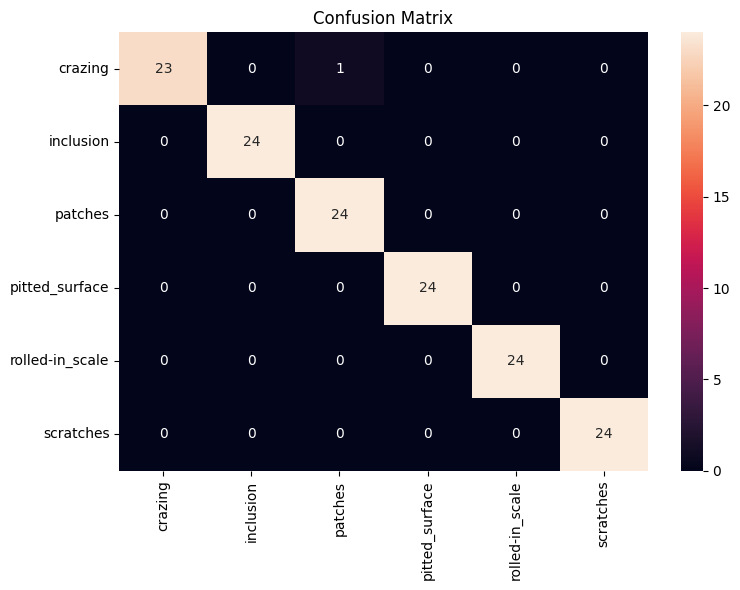

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(test_labels.numpy(), test_preds.numpy(), target_names=CLASS_NAMES))

cm = confusion_matrix(test_labels.numpy(), test_preds.numpy())
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()